In [96]:
import numpy as np
import pandas as pd
import seaborn as sns
import seaborn.objects as so

from formulaic import Formula

# Herramientas de modelos lineales
from sklearn import linear_model  

# Medidas de desempeño
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error    

# Regresión Polinomial

### Laboratorio de Datos, IC - FCEN - UBA - 1C 2026

Buscamos los coeficientes de un polinomio de grado $n$
$$Y = \beta_0 + \beta_1 X + \beta_2 X^2 + \beta_3 X^3 + \dots + \beta_n X^n$$

que mejor aproxime a nuestros datos en el sentido de Cuadrados Mínimos. Es decir, buscamos $\beta_1,\dots, \beta_n$ que minimicen:
$$ RSS(\beta) = \displaystyle\sum_{i=1}^n (y_i - P(x_i))^2 $$

Vamos a usar como ejemplo los datos de PBI per capita de Argentina, del dataset `gapminder`

In [97]:
gapminder = pd.read_csv('practicas\gapminder.csv')
datos_arg = gapminder[gapminder['country'] == 'Argentina'].reset_index(drop=True)
datos_arg

<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
<>:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
C:\Users\s94-e\AppData\Local\Temp\ipykernel_10172\1521681973.py:1: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  gapminder = pd.read_csv('practicas\gapminder.csv')


,country,continent,year,lifeExp,pop,gdpPercap
0,Argentina,Americas,1952,62.485,17876956,5911.315053
1,Argentina,Americas,1957,64.399,19610538,6856.856212
2,Argentina,Americas,1962,65.142,21283783,7133.166023
3,Argentina,Americas,1967,65.634,22934225,8052.953021
4,Argentina,Americas,1972,67.065,24779799,9443.038526
5,Argentina,Americas,1977,68.481,26983828,10079.026740
6,Argentina,Americas,1982,69.942,29341374,8997.897412
7,Argentina,Americas,1987,70.774,31620918,9139.671389
8,Argentina,Americas,1992,71.868,33958947,9308.418710
9,Argentina,Americas,1997,73.275,36203463,10967.281950


### Visualización

Teníamos la visualización de la Regresión Lineal:

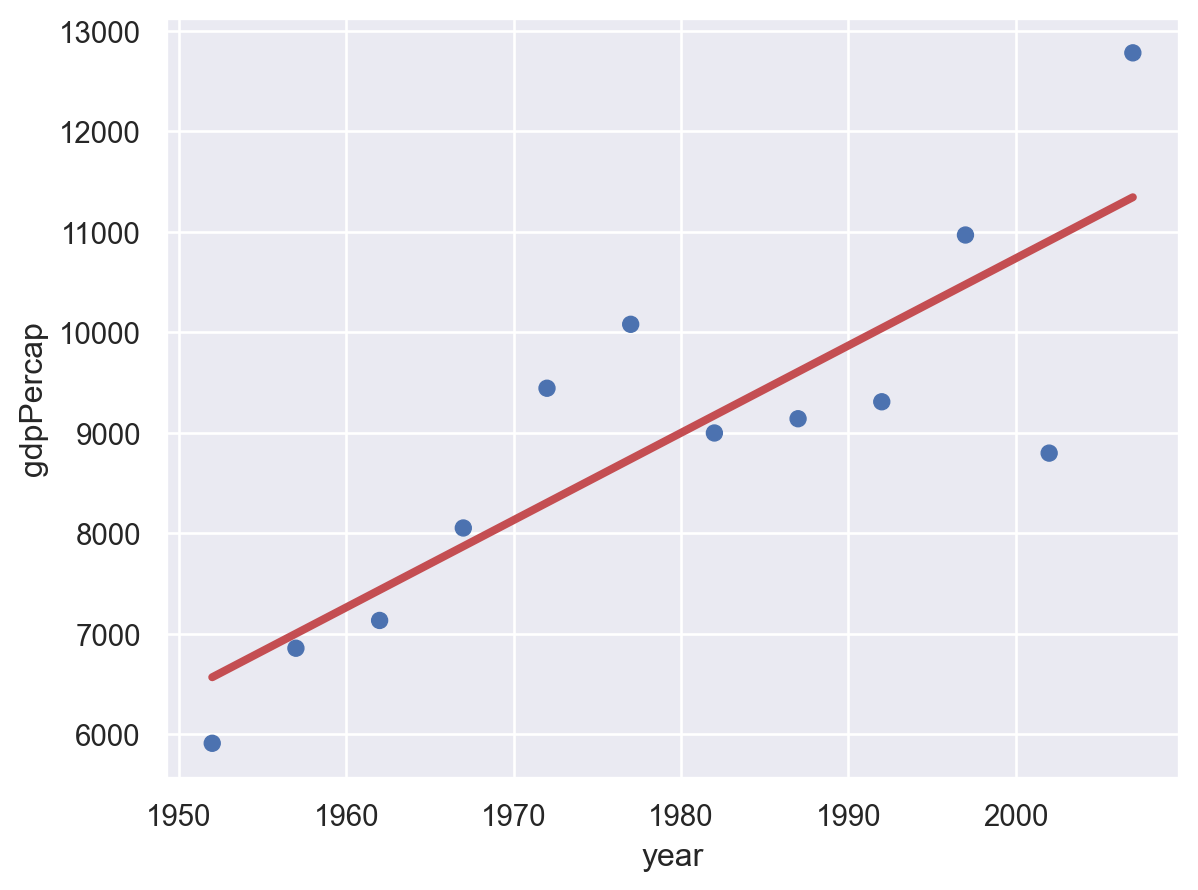

In [98]:
(
    so.Plot(data=datos_arg, x='year', y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(1))
)

Calculemos el $R^2$ de la Regresión Lineal:

In [99]:
# Escribimos la fórmula
y, X = Formula('gdpPercap ~ year').get_model_matrix(datos_arg)

# Inicializamos el modelo de regresión
modelo = linear_model.LinearRegression(fit_intercept=False)

# Realizamos el ajuste
modelo.fit(X, y)

# Calculamos R²
y_pred = modelo.predict(X)
r2_score(datos_arg['gdpPercap'], y_pred)

0.7060056670920914

Para cambiar el grado del polinomio que ajusta los datos en Seaborn, simplemente cambios el argumento de `so.PolyFit`. Por ejemplo, para un polinomio de grado $???$:

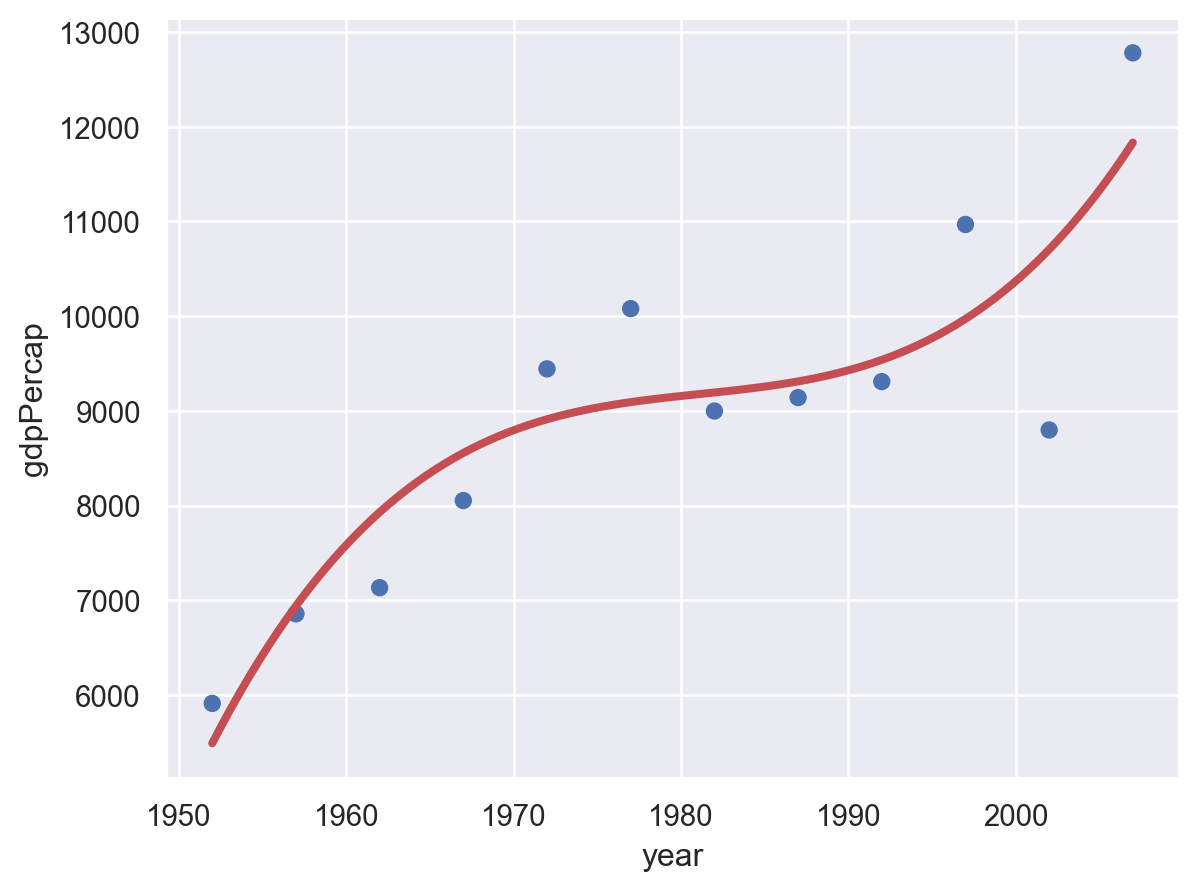

In [100]:
(
    so.Plot(data=datos_arg, x=datos_arg['year'], y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='r', linewidth=3), so.PolyFit(3))
)

### Cálculo de coeficientes y de predicciones

Queremos buscar el polinomio de grado 3 que mejor aproxima a los datos en sentido de cuadrados mínimos:
$$P(x) = \beta_0 + \beta_1 x + \beta_2 x^ 2 + \beta_3 x^ 3$$

Calcularemos los coeficientes con `scikit-learn`. Es parecido a lo que hacíamos con la regresión lineal, pero con un paso extra: tenemos que construir la matriz de datos agregando columnas para $x^2$ y $x^3$.

### Formulaic: implementación de alto rendimiento de las fórmulas de Wilkinson para Python.

Aunque perfectamente podemos hacer la matriz "a mano", el paquete Formulaic nos permite hacerla automáticamente para polinomios de cualquier grado.

In [101]:
# poly(year,3) significa que usamos un polinomio de grado 3 cuya variable es year
# raw = True nos da los datos "crudos", es decir genera columnas x, x^2 y x^3 sin ninguna transformación ni normalización.
# -1 significa que no queremos una columna de 1's en la matriz para el intercept

y, X = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').get_model_matrix(datos_arg)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

In [102]:
X

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


In [103]:
y

0      5911.315053
1      6856.856212
2      7133.166023
3      8052.953021
4      9443.038526
5     10079.026740
6      8997.897412
7      9139.671389
8      9308.418710
9     10967.281950
10     8797.640716
11    12779.379640
Name: gdpPercap, dtype: float64

In [104]:
# Inicializamos el modelo de regresión. 
modelo = linear_model.LinearRegression(fit_intercept=True)

# Realiza el ajuste
modelo.fit(X, y)

# Como usamos fit_intercept = True, la ordenada al origen está en modelo.intercept_
ordenada_al_origen = modelo.intercept_

# Recuperamos los valores de los demas coeficientes (de menor potencia a la mayor)
coeficientes = modelo.coef_

# Armamos el array con los valores de beta
beta = np.array([ordenada_al_origen, *coeficientes])

# Imprimimos los valores:
print('beta_0: ', beta[0])
print('beta_1: ', beta[1])
print('beta_2: ', beta[2])
print('beta_3: ', beta[3])

beta_0:  -984937719.586078
beta_1:  1491410.4188657836
beta_2:  -752.7757907740632
beta_3:  0.1266538016727208


El polinomio de grado a lo sumo 3 que mejor aproxima a los datos es:
$$P(x) = -984937719.58 + 1491410.41 x -752.77 x^ 2 + 0.12 x^ 3 $$

Corroboremos que el gráfico de este polinomio es el mismo que arma `seaborn` con `so.PolyFit`:

In [105]:
X



,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1952,3810304,7437713408
1,1957,3829849,7495014493
2,1962,3849444,7552609128
3,1967,3869089,7610498063
4,1972,3888784,7668682048
5,1977,3908529,7727161833
6,1982,3928324,7785938168
7,1987,3948169,7845011803
8,1992,3968064,7904383488
9,1997,3988009,7964053973


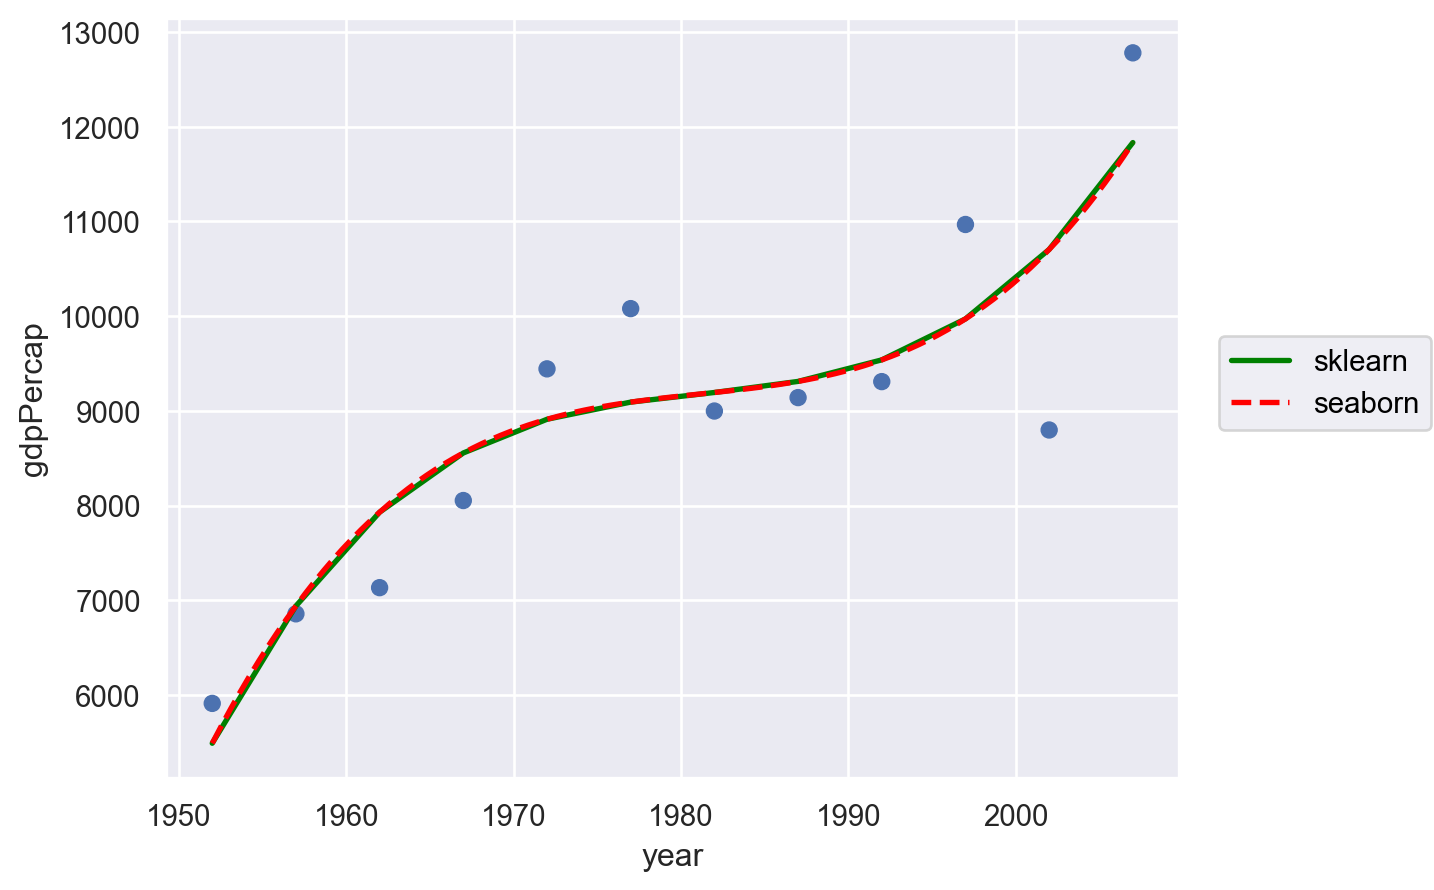

In [106]:
(
    so.Plot(data=datos_arg, x='year', y='gdpPercap')
    .add(so.Dot())
    .add(so.Line(color='green', linewidth=2),
         y=modelo.predict(X),
         label='sklearn')
    .add(so.Line(color='red', linestyle='--', linewidth=2),
         so.PolyFit(3),
         label='seaborn')
    .label()
)

Igual que antes, podemos estimar el PBI per capita, por ejemplo para 1990 y 2015:

* haciendo las cuentas

In [107]:
# Haciendo las cuentas a mano
prediccion_1990 = beta[0] + beta[1]*1990 + beta[2]*(1990**2) + beta[3]*(1990**3)

# O usando numpy
prediccion_2015 = beta @ 2015**np.arange(4, dtype='int64')

print('Prediccion 1990: ', prediccion_1990)
print('Prediccion 2015: ', prediccion_2015)

Prediccion 1990:  9427.720705151558
Prediccion 2015:  14697.104549998006


* usando `predict`

In [108]:
# Armamos un DataFrame con los datos de x a los cuales les queremos aplicar el modelo
nuevos = pd.DataFrame({"year":  [1990, 2015]})

# Armamos el DataFrame para pasarle a predict
datos_a_predecir = Formula('gdpPercap ~ poly(year, 3, raw=True) - 1').rhs.get_model_matrix(nuevos)   #rhs (right hand side) nos da solo x
datos_a_predecir

,"poly(year, 3, raw=True)[0]","poly(year, 3, raw=True)[1]","poly(year, 3, raw=True)[2]"
0,1990,3960100,7880599000
1,2015,4060225,8181353375


In [109]:
modelo.predict(datos_a_predecir)

array([ 9427.72070551, 14697.10454977])

También podemos calcular las medidas de desempeño del modelo:

In [110]:
y_pred = modelo.predict(X)

# Calculando el R^2
r2 = r2_score(datos_arg['gdpPercap'], y_pred)
print('R^2: ', r2)

# Calculando el ECM
ecm = mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('ECM: ', ecm)

# Calculando la RECM
recm = root_mean_squared_error(datos_arg['gdpPercap'], y_pred)
print('RECM: ', recm)

R^2:  0.7910974741181276
ECM:  664333.9856709568
RECM:  815.0668596323598


## Regresión con funciones bases

Vamos a trabajar con mediciones de dióxido de carbono en el aire en el observatorio de Mauna Loa (Hawaii)

In [111]:
# Cargamos los datos y graficamos
data = pd.read_csv('co2_hawaii.csv')
data

,fecha,co2
0,1958-03-31,316.100000
1,1958-04-30,317.200000
2,1958-05-31,317.433333
3,1958-07-31,315.625000
4,1958-08-31,314.950000
...,...,...
516,2001-08-31,369.425000
517,2001-09-30,367.880000
518,2001-10-31,368.050000
519,2001-11-30,369.375000


In [112]:
# Tomamos la fecha como indice
data = data.set_index("fecha")
data

,co2
fecha,
1958-03-31,316.100000
1958-04-30,317.200000
1958-05-31,317.433333
1958-07-31,315.625000
1958-08-31,314.950000
...,...
2001-08-31,369.425000
2001-09-30,367.880000
2001-10-31,368.050000


In [113]:
type(data)

pandas.core.frame.DataFrame

<Axes: xlabel='fecha'>

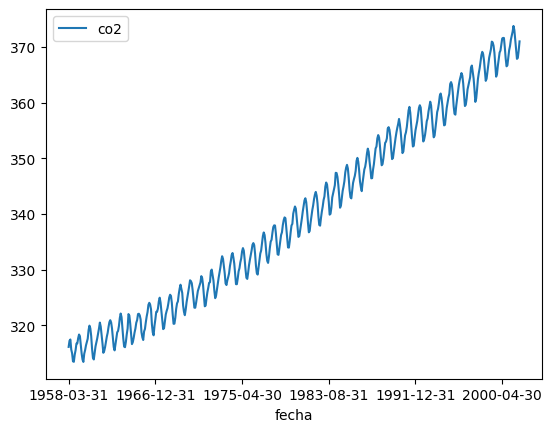

In [114]:
# Graficamos
data.plot()

Queremos ajustar a los datos una función de la forma
$$
co2 = \beta_0 + \beta_1 * mes + \beta_2 * \sin\left(2 \pi *  \frac{mes}{12}\right)
$$

Construimos una matriz $X$ con una columna para el mes y otra columna para el seno.

In [115]:
# ¿Cuántos meses hay en los datos?
data.co2.size

521

In [116]:
mes = np.arange(521)
datos_transformados = pd.DataFrame(
    {
        "mes": mes,
        "sinx": 2*np.sin(2*np.pi*mes/12),
        "co2": data["co2"]
    },
    index=data.index
)
datos_transformados

,mes,sinx,co2
fecha,,,
1958-03-31,0,0.000000e+00,316.100000
1958-04-30,1,1.000000e+00,317.200000
1958-05-31,2,1.732051e+00,317.433333
1958-07-31,3,2.000000e+00,315.625000
1958-08-31,4,1.732051e+00,314.950000
...,...,...,...
2001-08-31,516,-3.527478e-14,369.425000
2001-09-30,517,1.000000e+00,367.880000
2001-10-31,518,1.732051e+00,368.050000


In [117]:
# Ajustamos el modelo

y, X = Formula('co2 ~ mes + sinx').get_model_matrix(datos_transformados)
y = y.iloc[:, 0]  # Convertimos el DataFrame a Series

# Inicializamos el modelo de regresión
modeloCO2 = linear_model.LinearRegression(fit_intercept=True)

# Realizamos el ajuste
modeloCO2.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [118]:
# Predecimos
y_pred = modeloCO2.predict(X)

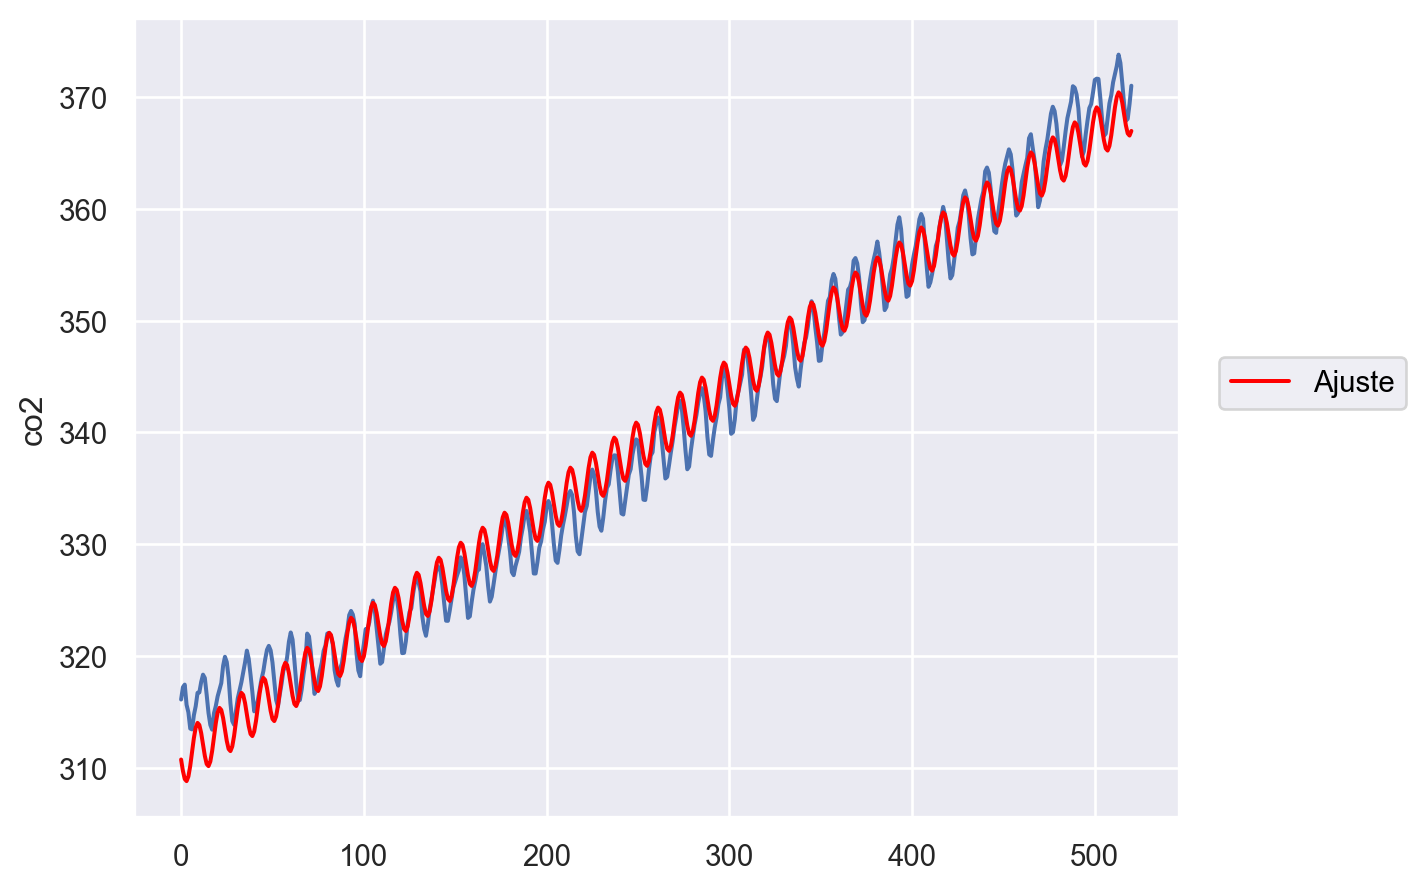

In [119]:
# Graficamos
(
    so.Plot()  # Podemos usar también x = data.index pero no se ve bien
    .add(so.Line(), data=data, x = mes, y="co2")
    .add(so.Line(color = "red"), x=mes, y=y_pred, label='Ajuste')
)

In [120]:
# Calculando el R^2
r2 = r2_score(data["co2"], y_pred)
print('R^2: ', r2*100)

R^2:  98.4074298149345


## Residuos
El $R^2$ nos dio muy bien! Se podrá mejorar?
Veamos los residuos...

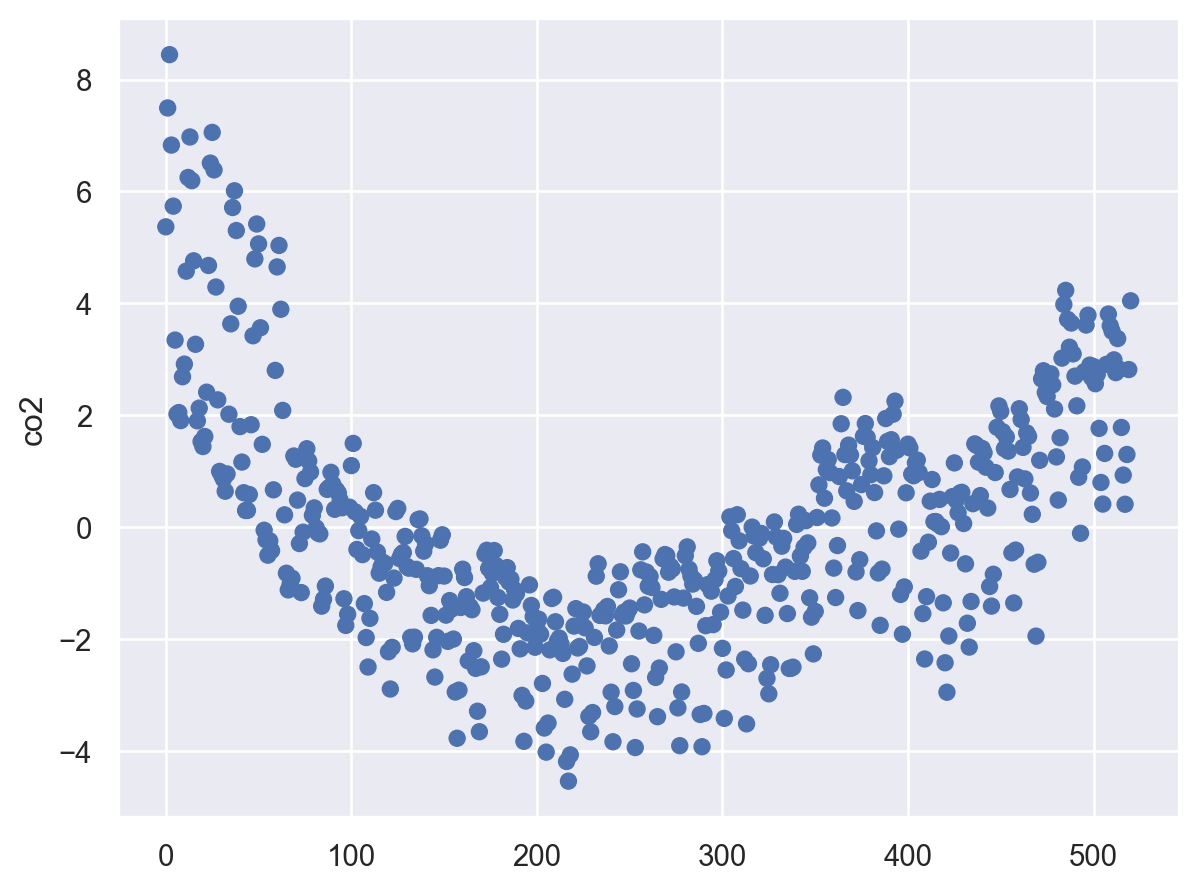

In [121]:
residuos = data["co2"] - y_pred
(
    so.Plot(x=mes, y=residuos)
    .add(so.Dot())
)

Los residuos no parecen al azar... ¡podemos mejorar el ajuste!

## Ejercicio

Agregar otras funciones base al modelo y ver si mejora el ajuste en el gráfico y el $R^2$.

Recordar que solo podemos usar una combinación lineal de funciones base.

In [122]:
datos_transformados['cosx'] = 2*np.cos(2*np.pi*mes/12)
y, X = Formula('co2 ~ mes + sinx + cosx').get_model_matrix(datos_transformados)
y = y.iloc[:, 0]


In [123]:
modeloC02_v2 = linear_model.LinearRegression(fit_intercept= True)
modeloC02_v2.fit(X,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [124]:
y_pred_v2 = modeloC02_v2.predict(X)

In [125]:
r2_viejo = r2
r2 = r2_score(data["co2"], y_pred_v2)
print('R^2', r2*100)
print('R^2 viejo', r2_viejo*100)

R^2 98.47366583949109
R^2 viejo 98.4074298149345


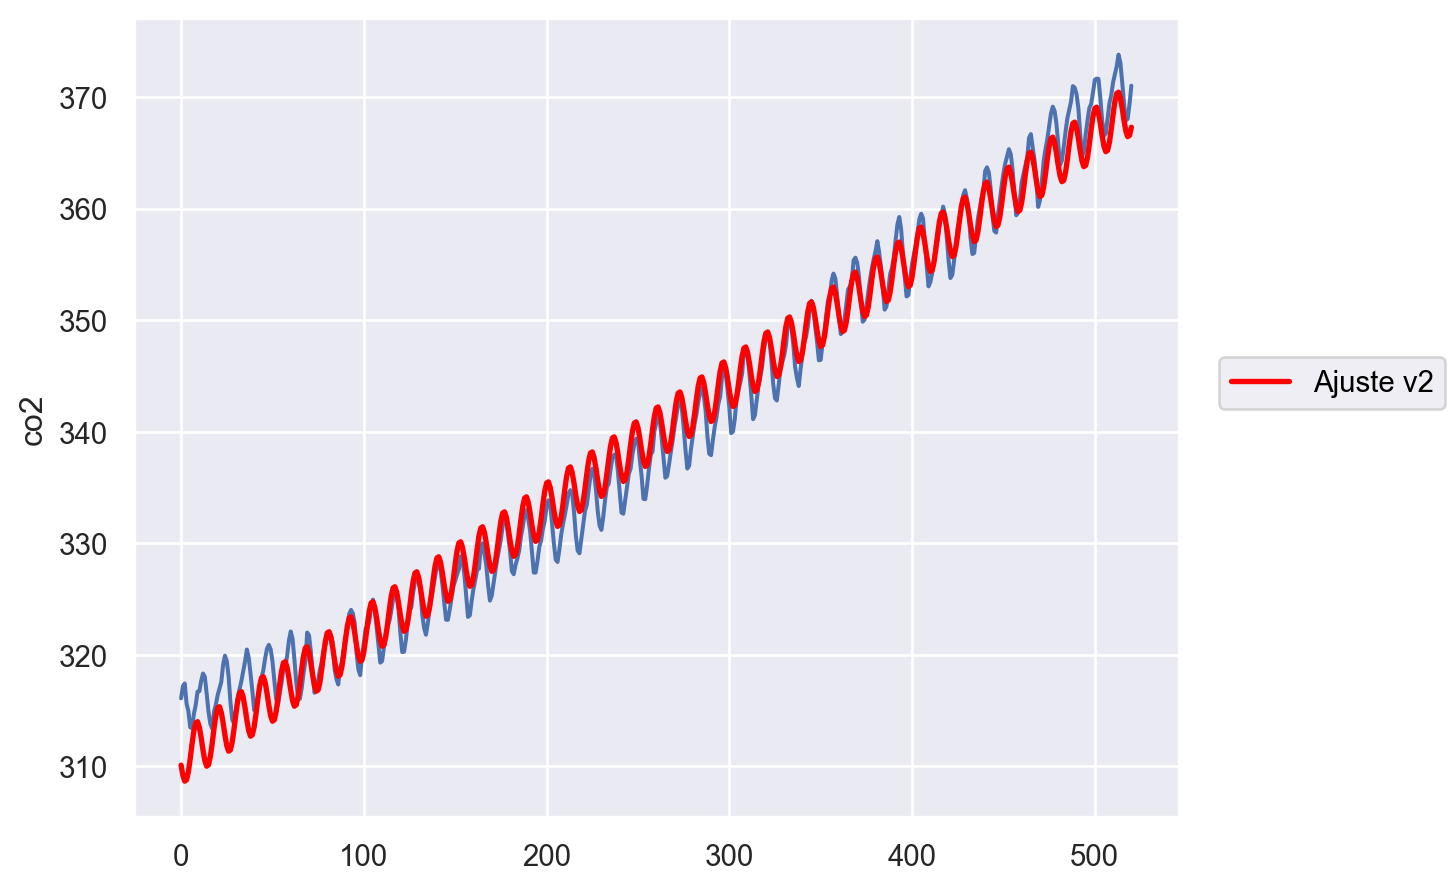

In [126]:
(
    so.Plot()
    .add(so.Line(),
         data = data,
         x = mes,
         y = 'co2')
    .add(so.Line(color= 'red', linewidth= 2),
         x = mes,
         y = y_pred_v2,
         label = 'Ajuste v2')
    .label()
    
)

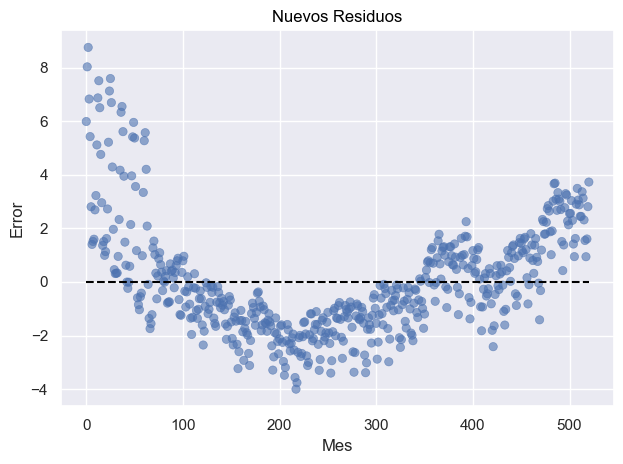

In [133]:
residuos_avanzados = data["co2"] - y_pred_v2

(
    # Cambiamos data["mes"] por la variable mes directamente
    so.Plot(x=mes, y=residuos_avanzados)
    .add(so.Dot(alpha=0.6))
    .add(so.Line(color='black', linestyle='--'), x=mes, y=0) # Línea de referencia en 0
    .label(title="Nuevos Residuos", x="Mes", y="Error")
).show()